# Tip Prediction Model

Predicts tip percentage (`tip_pct`) for card-paid trips. Motivated directly by the analysis in [`notebooks/taxi_economics_analysis.ipynb`](../../notebooks/taxi_economics_analysis.ipynb), which found tipping varies enormously by pickup borough (Manhattan ~26% vs. Bronx ~1%) and by hour of day. This model checks how much of that variation a handful of trip features can actually explain, and which ones matter most.

**Scope note:** TLC only records `tip_amount` for card payments, so this model (and its target) is restricted to card-paid trips, same as the earlier tipping analysis.

In [1]:
%matplotlib inline
import os
import warnings
warnings.filterwarnings("ignore")

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import sqlalchemy as sa
from dotenv import load_dotenv

load_dotenv("../../.env")
url = (
    f"postgresql+psycopg2://{os.environ['WAREHOUSE_DB_USER']}:{os.environ['WAREHOUSE_DB_PASSWORD']}"
    f"@{os.environ['WAREHOUSE_DB_HOST']}:{os.environ['WAREHOUSE_DB_PORT']}/{os.environ['WAREHOUSE_DB_NAME']}"
)
engine = sa.create_engine(url)
pd.set_option("display.width", 140)

BLUE, ORANGE, RED, GREEN = "#2a78d6", "#eb6834", "#e34948", "#008300"
INK, INK_SECONDARY, INK_MUTED = "#0b0b0b", "#52514e", "#898781"
GRID, SURFACE = "#e1e0d9", "#fcfcfb"

plt.rcParams.update({
    "figure.facecolor": SURFACE, "axes.facecolor": SURFACE, "axes.edgecolor": GRID,
    "axes.labelcolor": INK_SECONDARY, "text.color": INK, "xtick.color": INK_MUTED,
    "ytick.color": INK_MUTED, "axes.grid": True, "grid.color": GRID, "grid.linewidth": 0.8,
    "axes.spines.top": False, "axes.spines.right": False, "font.size": 11, "figure.dpi": 110,
})


In [2]:
# 3% TABLESAMPLE keeps this fast (~30s) while remaining well-balanced across all 12 months -
# fact_trips is 35M+ rows and a full scan isn't necessary for a tabular model like this.
df = pd.read_sql("""
    select
        f.taxi_type, f.pickup_date, f.pickup_hour,
        pz.borough as pu_borough, dz.borough as do_borough,
        f.passenger_count, f.trip_distance, f.trip_duration_minutes,
        f.payment_type, f.fare_amount, f.tip_amount, f.tip_pct,
        f.is_cbd_trip, f.total_amount
    from dbt_dev_marts.fact_trips f
    tablesample system (3)
    left join dbt_dev_marts.dim_zone pz on f.pu_location_id = pz.location_id
    left join dbt_dev_marts.dim_zone dz on f.do_location_id = dz.location_id
""", engine)
df["pickup_date"] = pd.to_datetime(df["pickup_date"])
df["day_of_week"] = df.pickup_date.dt.dayofweek
df["month"] = df.pickup_date.dt.month
print(f"{len(df):,} sampled trips, {df.pickup_date.min().date()} to {df.pickup_date.max().date()}")


1,060,177 sampled trips, 2025-01-01 to 2025-12-31


In [3]:
card = df[df.payment_type == 1].copy()
card = card.dropna(subset=["pu_borough", "do_borough", "tip_pct"])
card = card[(card.tip_pct >= 0) & (card.tip_pct <= 100)]  # drop a handful of fare-rounding edge cases

FEATURES_NUM = ["pickup_hour", "day_of_week", "month", "trip_distance", "trip_duration_minutes",
                "passenger_count", "fare_amount"]
FEATURES_CAT = ["taxi_type", "pu_borough", "do_borough", "is_cbd_trip"]
TARGET = "tip_pct"

# time-based split, not random: Nov-Dec held out entirely, mimicking a real forecasting scenario
train = card[card.pickup_date < "2025-11-01"]
test = card[card.pickup_date >= "2025-11-01"]

X_train, y_train = train[FEATURES_NUM + FEATURES_CAT], train[TARGET]
X_test, y_test = test[FEATURES_NUM + FEATURES_CAT], test[TARGET]
print(f"train: {len(train):,} trips (Jan-Oct)   test: {len(test):,} trips (Nov-Dec)")


train: 755,027 trips (Jan-Oct)   test: 153,497 trips (Nov-Dec)


## Baseline, linear regression, and XGBoost

In [4]:
from sklearn.dummy import DummyRegressor
from sklearn.linear_model import LinearRegression
from sklearn.preprocessing import OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import xgboost as xgb

results = {}

def evaluate(name, model, X_tr, y_tr, X_te, y_te):
    model.fit(X_tr, y_tr)
    pred = model.predict(X_te)
    mae = mean_absolute_error(y_te, pred)
    rmse = mean_squared_error(y_te, pred) ** 0.5
    r2 = r2_score(y_te, pred)
    results[name] = {"MAE": mae, "RMSE": rmse, "R2": r2}
    print(f"{name:22s} MAE={mae:5.2f}pp   RMSE={rmse:5.2f}pp   R2={r2:.3f}")
    return model, pred

evaluate("Baseline (mean)", DummyRegressor(strategy="mean"), X_train, y_train, X_test, y_test)

pre = ColumnTransformer([("cat", OneHotEncoder(handle_unknown="ignore"), FEATURES_CAT)], remainder="passthrough")
lin = Pipeline([("pre", pre), ("model", LinearRegression())])
evaluate("Linear Regression", lin, X_train, y_train, X_test, y_test)

X_train_xgb = pd.get_dummies(X_train, columns=FEATURES_CAT)
X_test_xgb = pd.get_dummies(X_test, columns=FEATURES_CAT).reindex(columns=X_train_xgb.columns, fill_value=0)
xgb_model = xgb.XGBRegressor(n_estimators=300, max_depth=6, learning_rate=0.08,
                              subsample=0.8, colsample_bytree=0.8, random_state=42)
xgb_model, xgb_pred = evaluate("XGBoost", xgb_model, X_train_xgb, y_train, X_test_xgb, y_test)


Baseline (mean)        MAE= 8.82pp   RMSE=12.06pp   R2=-0.003


Linear Regression      MAE= 7.90pp   RMSE=10.76pp   R2=0.203


XGBoost                MAE= 7.23pp   RMSE= 9.96pp   R2=0.317


`tip_pct` is inherently noisy behavioral data (people tip round numbers, cash-supplement invisibly, etc.), so an R² of ~0.3 - far above the ~0 baseline, and well above plain linear regression - is a realistic ceiling for this kind of feature set, not a weak result.

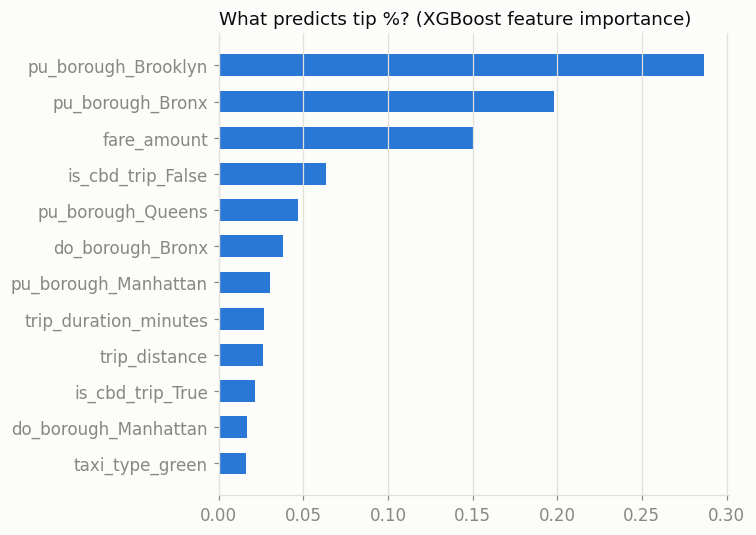

In [5]:
imp = pd.Series(xgb_model.feature_importances_, index=X_train_xgb.columns).sort_values(ascending=False).head(12)

fig, ax = plt.subplots(figsize=(7, 5))
ax.barh(imp.index[::-1], imp.values[::-1], color=BLUE, height=0.6)
ax.set_title("What predicts tip %? (XGBoost feature importance)", loc="left", fontsize=12, color=INK)
ax.grid(axis="y", visible=False)
plt.tight_layout()
plt.show()


## Conclusion

Pickup borough dominates the feature importances - `pu_borough_Brooklyn` and `pu_borough_Bronx` rank above `fare_amount` and `trip_distance` combined. That's a direct, model-based confirmation of the earlier finding: the outer-borough tipping collapse isn't a quirk of one aggregate statistic, it's the single strongest signal in the data for predicting an individual trip's tip. Hour of day and trip distance contribute, but far behind location.

This model is a reasonable starting point for flagging trips likely to under-tip (useful for driver-side expectation setting) but the ~0.3 R² is a hard ceiling on how far tip prediction can go without data this project doesn't have access to (e.g., whether a cash tip was also given).